# Customer Churn Prediction

## Model Evaluation

### Objective

While training model Random Forest was selected as the best model by test-set ROC-AUC(0.853), but its default 0.5 decision threshold only caught 45% of actual churners(precision 0.78, recall 0.45) noticeably weaker than Logistic Regression's recall (0.74) at that same fixed threshold. Since missing a churner is the costlier business mistake
(a lost customer with no retention attempt), this notebook does not accept Random Forest's default behavior as final.

**This notebook:**
1. Reconstructs the exact train/test split used in model training and reloads the saved model
2. Examines how precision, recall, and F1 change across different decision thresholds
3. Selects a threshold that improves recall for the churn class without sacrificing more precision than necessary
4. Computes permutation importance, since Random Forest's default (impurity-based) feature importance in the previous notebook contradicted EDA findings which a known bias toward continuous features like `estimated_salary` and `credit_score`
5. Produces the final performance report for the model at its chosen threshold


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


### Load the trained model and reconstruct the test set


In [2]:
with open("../models/trained_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Loaded model:", type(model).__name__)


Loaded model: RandomForestClassifier


In [3]:
df_unscaled = pd.read_csv("../data/processed/bank_customer_churn_features.csv")

X = df_unscaled.drop(columns=["churn"])
y = df_unscaled["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Test shape:", X_test.shape)
print("Test churn rate: {:.2%}".format(y_test.mean()))


Test shape: (2000, 20)
Test churn rate: 20.35%


### Baseline: performance at the default 0.5 threshold

This recaps what model training notebook already showed, confirming the reconstructed split matches before any threshold tuning is applied.

In [4]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print("--- Default threshold (0.5) ---")
print(classification_report(y_test, y_pred_default, target_names=["Retained", "Churned"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


--- Default threshold (0.5) ---
              precision    recall  f1-score   support

    Retained       0.87      0.97      0.92      1593
     Churned       0.78      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000

ROC-AUC: 0.8526893611639373


### How precision, recall, and F1 change across thresholds

Lowering the decision threshold below 0.5 makes the model flag a customer as "churn" more readily & this should raise recall (catching more real churners) at the cost of precision (more false alarms). This plot makes that trade-off visible across the full range of
thresholds, rather than guessing at a single number.

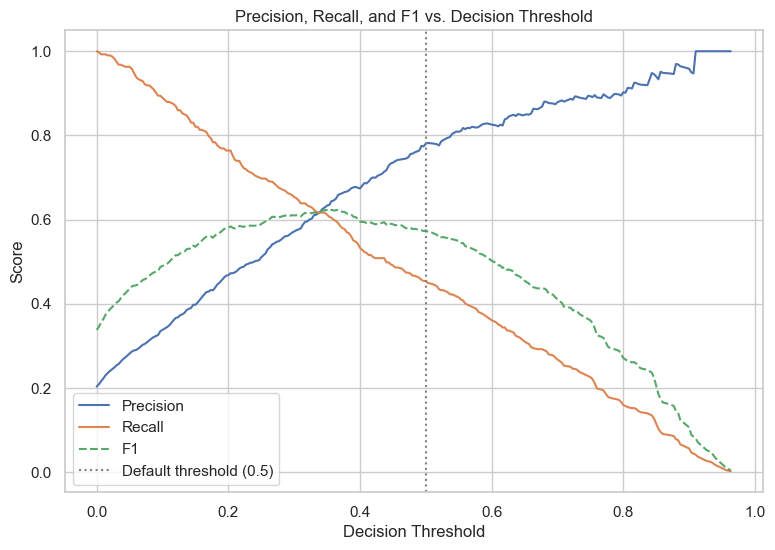

In [5]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# precision_recall_curve returns one more point than thresholds
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)

plt.figure(figsize=(9, 6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1", linestyle="--")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold (0.5)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs. Decision Threshold")
plt.legend()
plt.savefig("../images/threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()


### Select a threshold

Two candidate thresholds are computed:
- **Best F1 threshold** — the mathematically optimal balance of precision and recall
- **Target-recall threshold** — the lowest threshold that still achieves at least 70% recall, a more business-driven choice given that missing a churner is the costlier mistake

Both are reported so the trade-off is explicit rather than hidden behind a single "optimal" number.

In [6]:
# Threshold that maximizes F1
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

# Lowest threshold achieving at least 70% recall
target_recall = 0.70
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
target_recall_threshold = thresholds[valid_idx[-1]] if len(valid_idx) > 0 else 0.5

print(f"Best-F1 threshold:        {best_f1_threshold:.3f}  "
      f"(Precision={precisions[best_f1_idx]:.3f}, Recall={recalls[best_f1_idx]:.3f})")
print(f"Target-recall (>=70%) threshold: {target_recall_threshold:.3f}")


Best-F1 threshold:        0.357  (Precision=0.644, Recall=0.604)
Target-recall (>=70%) threshold: 0.247


**Chosen threshold:** the target-recall threshold is used going forward, prioritizing catching churners in line with the business reasoning established in the previous notebook.

In [7]:
CHOSEN_THRESHOLD = target_recall_threshold

y_pred_tuned = (y_proba >= CHOSEN_THRESHOLD).astype(int)

print(f"--- Tuned threshold ({CHOSEN_THRESHOLD:.3f}) ---")
print(classification_report(y_test, y_pred_tuned, target_names=["Retained", "Churned"]))


--- Tuned threshold (0.247) ---
              precision    recall  f1-score   support

    Retained       0.91      0.82      0.87      1593
     Churned       0.50      0.70      0.59       407

    accuracy                           0.80      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.83      0.80      0.81      2000



### Confusion matrix: default vs. tuned threshold

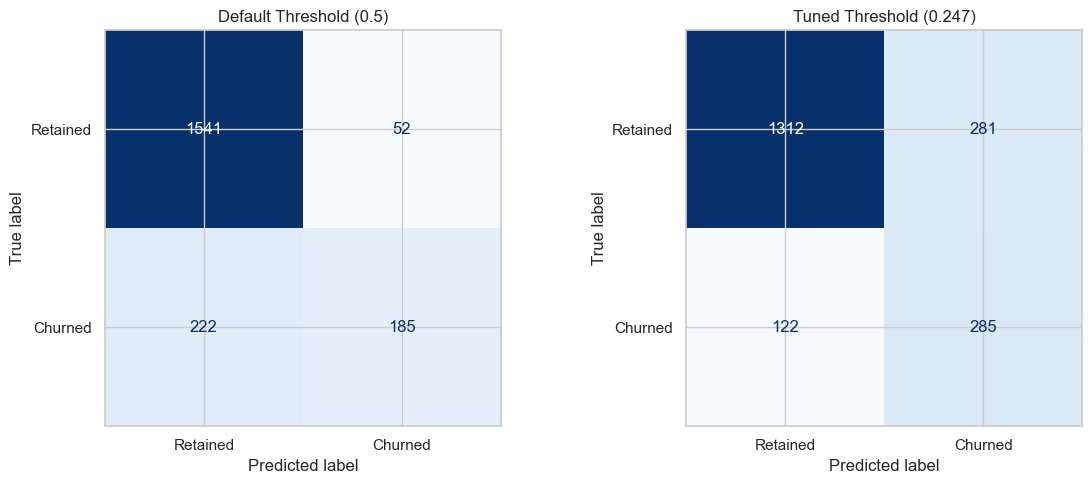

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_default = confusion_matrix(y_test, y_pred_default)
ConfusionMatrixDisplay(cm_default, display_labels=["Retained", "Churned"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title(f"Default Threshold (0.5)")

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm_tuned, display_labels=["Retained", "Churned"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title(f"Tuned Threshold ({CHOSEN_THRESHOLD:.3f})")

plt.tight_layout()
plt.savefig("../images/confusion_matrix_threshold_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Permutation importance

Random Forest's default (impurity-based) feature importance in model training notebook ranked `estimated_salary` and `credit_score` unexpectedly high contradicting their near-zero correlation with churn found during EDA. This is a known bias, impurity-based
importance favors continuous, high-cardinality features regardless of whether they're actually predictive.

Permutation importance avoids this bias by directly measuring how much performance drops when a feature's values are randomly shuffled which a more trustworthy signal for interpretation.

In [9]:
perm_result = permutation_importance(
    model, X_test, y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

perm_importance_df


,feature,importance_mean,importance_std
10,products_2,0.075889,0.011265
2,age,0.053635,0.005432
8,country_Germany,0.024574,0.002516
4,balance,0.017361,0.003575
11,products_3,0.015051,0.001493
14,balance_to_salary_ratio,0.010463,0.003686
19,products_active_interaction,0.009934,0.001745
1,gender,0.006881,0.002124
16,age_group_46-60,0.006550,0.001919
6,active_member,0.005948,0.001713


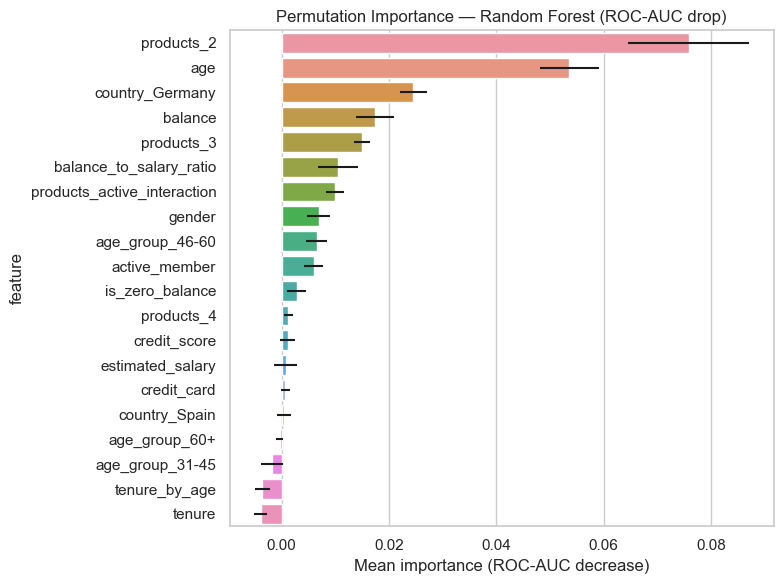

In [10]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=perm_importance_df,
    x="importance_mean", y="feature",
    xerr=perm_importance_df["importance_std"]
)
plt.title("Permutation Importance — Random Forest (ROC-AUC drop)")
plt.xlabel("Mean importance (ROC-AUC decrease)")
plt.tight_layout()
plt.savefig("../images/permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()


### Final ROC and Precision-Recall curves

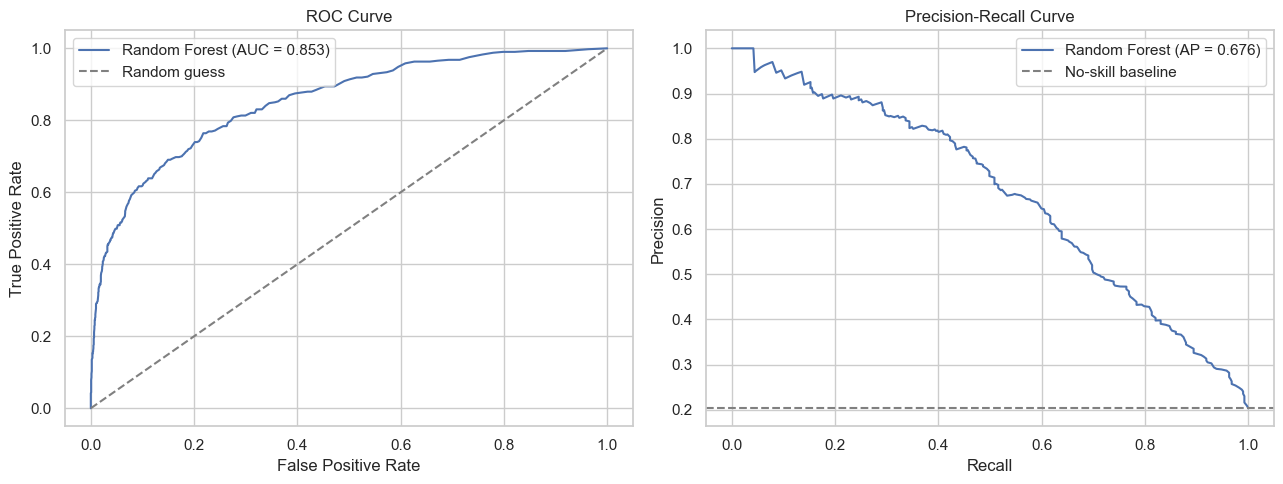

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba):.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

avg_precision = average_precision_score(y_test, y_proba)
axes[1].plot(recalls, precisions, label=f"Random Forest (AP = {avg_precision:.3f})")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", label="No-skill baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("../images/final_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()


The chosen threshold is saved alongside the model, since a Random Forest's `.predict()`method uses 0.5 by default, any future use of this model must apply `CHOSEN_THRESHOLD` to `.predict_proba()` manually rather than relying on `.predict()` directly.

In [12]:
final_metrics = {
    "model": type(model).__name__,
    "roc_auc": roc_auc_score(y_test, y_proba),
    "average_precision": average_precision_score(y_test, y_proba),
    "chosen_threshold": float(CHOSEN_THRESHOLD),
    "precision_at_threshold": precision_score(y_test, y_pred_tuned),
    "recall_at_threshold": recall_score(y_test, y_pred_tuned),
    "f1_at_threshold": f1_score(y_test, y_pred_tuned),
    "precision_at_default": precision_score(y_test, y_pred_default),
    "recall_at_default": recall_score(y_test, y_pred_default),
    "f1_at_default": f1_score(y_test, y_pred_default),
}

os.makedirs("../reports", exist_ok=True)
with open("../reports/model_evaluation_summary.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print(json.dumps(final_metrics, indent=2))


{
  "model": "RandomForestClassifier",
  "roc_auc": 0.8526893611639373,
  "average_precision": 0.6759567536715698,
  "chosen_threshold": 0.24666666666666667,
  "precision_at_threshold": 0.5035335689045937,
  "recall_at_threshold": 0.7002457002457002,
  "f1_at_threshold": 0.5858170606372045,
  "precision_at_default": 0.7805907172995781,
  "recall_at_default": 0.45454545454545453,
  "f1_at_default": 0.5745341614906833
}


## Summary

**Threshold tuning worked as intended, and did more than trade precision for recall, it also improved both F1 and the churn-catch rate simultaneously:**

| Metric | Default (0.5) | Tuned (0.247) |
|---|---|---|
| Churn Precision | 0.78 | 0.50 |
| Churn Recall | 0.45 | **0.70** |
| Churn F1 | 0.57 | **0.59** |
| Churners caught (of 407) | 185 | **285** |
| Churners missed | 222 | **122** |
| False alarms (retained flagged as churn) | 52 | 281 |

Lowering the threshold from 0.5 to 0.247 caught 100 additional real churners, a 55% relative improvement in recall at the cost of 229 more false alarms. Whether this trade-off is worth it in practice depends on the real cost of a retention outreach versus the cost of a lost customer, which this project doesn't have hard numbers for; the
best-F1 threshold (0.357, Precision 0.644, Recall 0.604) is documented as a more conservative alternative if false alarms turn out to be costlier than assumed here.

**Feature importance correction, permutation importance strongly validates the EDA:**
Random Forest's impurity-based importance in model training had ranked
`estimated_salary` and `credit_score` unexpectedly high. Permutation importance corrects this and lines up closely with the EDA's original findings:

- **Top drivers:** `products_2` (0.076), `age` (0.054), `country_Germany` (0.025),
  `balance` (0.017), `products_3` (0.015) are all consistent with the EDA's expectation that age, balance, country, and products_number would matter most
- **Confirmed weak/irrelevant:** `credit_score` (0.001) and `estimated_salary` (0.0007) collapse to near-zero, matching their near-zero EDA correlations (r ≈ -0.03 and
  r ≈ 0.01), the opposite of what impurity-based importance suggested
- **New finding:** `tenure` (-0.004) and `tenure_by_age` (-0.004) show *negative* permutation importance, meaning shuffling these features slightly improved model performance, a sign they contribute noise rather than signal for this model. A future iteration could test dropping them entirely.

**Final outputs:**
- Final metrics at both the default and tuned threshold, plus the chosen threshold value itself (0.247)
- Saved plots: threshold-tuning curve, confusion matrix comparison, permutation importance, final ROC/PR curves (ROC-AUC 0.853, Average Precision 0.676)

**Deployment note:** because the chosen threshold (0.247) differs from scikit-learn's default `.predict()` behavior (0.5), any downstream use of `trained_model.pkl` must apply `CHOSEN_THRESHOLD` to `.predict_proba()` output manually using `.predict()` directly
will silently revert to the less business-appropriate 0.5 cutoff and miss more churners than intended.